# BPL + DIP + 3 PEAKS

In [1]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')
sys.path.append('/home/mt/softwares/icarogw/')
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from icarogw.wrappers import m1m2_paired_bpl_triplepeak_dip
from CHIMERA.mass.paired import bpl_dip_two_peaks
from CHIMERA.mass import p_m1m2

params = {
    'alpha_1': 1.7723937807650858,
    'alpha_2': 5.063826317550281,
    'mmin': 0.9245569825399548,
    'mmax': 124.20678928592034,
    'mu_g_1': 8.903700220355121,
    'sigma_g_1': 0.8391676748455468,
    'lambda_g': 0.3274896479007529,
    'mu_g_2': 24.556312970528175,
    'sigma_g_2': 10.002284990279694,
    'lambda_1': 0.6348482960571541,
    'mu_g_3': 62.73443845058334,
    'sigma_g_3': 8.683579188378397,
    'lambda_2': 0.9357685300341941,
    'beta_bottom': 1.5835680997888992,
    'beta_top': 2.4359528976425393,
    'bottomsmooth': 0.08456654031744229,
    'topsmooth': 0.07731696292920931,
    'leftdip': 2.416688462245518,
    'rightdip': 8.017044339987327,
    'leftdipsmooth': 0.11437807134426872,
    'rightdipsmooth': 0.081615513156543,
    'deep': 0.5744362121512125,
}

# ============================================================================
# ICAROGW setup
# ============================================================================

mass_icaro = m1m2_paired_bpl_triplepeak_dip()
mass_icaro.update(**params)
m_grid = np.logspace(np.log10(params['mmin']), np.log10(params['mmax']), 500)
m1_grid, m2_grid = np.meshgrid(m_grid, m_grid, indexing='ij')

# ICAROGW 2D PDF
icarogw_pdf_2d = mass_icaro.pdf(m1_grid, m2_grid)

# ICAROGW 1D marginals
icarogw_pdf_m1 = np.trapz(icarogw_pdf_2d, x=m_grid, axis=1)
icarogw_pdf_m1 = icarogw_pdf_m1 / np.trapz(icarogw_pdf_m1, x=m_grid)

icarogw_pdf_m2 = np.trapz(icarogw_pdf_2d, x=m_grid, axis=0)
icarogw_pdf_m2 = icarogw_pdf_m2 / np.trapz(icarogw_pdf_m2, x=m_grid)

# ============================================================================
# CHIMERA setup
# ============================================================================

mass_chimera = bpl_dip_three_peaks()
chimera_params = {
    'm_low': params['mmin'],
    'm_high': params['mmax'],
    'alpha_1': params['alpha_1'],
    'alpha_2': params['alpha_2'],
    'beta_bottom': params['beta_bottom'],
    'beta_top': params['beta_top'],
    'mu_g1': params['mu_g_1'],
    'sigma_g1': params['sigma_g_1'],
    'mu_g2': params['mu_g_2'],
    'sigma_g2': params['sigma_g_2'],
    'mu_g3': params['mu_g_3'],
    'sigma_g3': params['sigma_g_3'],
    'lambda_g': params['lambda_g'],
    'lambda_1': params['lambda_1'],
    'lambda_2': params['lambda_2'],
    'bottomsmooth': params['bottomsmooth'],
    'topsmooth': params['topsmooth'],
    'leftdip': params['leftdip'],
    'rightdip': params['rightdip'],
    'leftdipsmooth': params['leftdipsmooth'],
    'rightdipsmooth': params['rightdipsmooth'],
    'deep': params['deep'],
}
mass_chimera = mass_chimera.update(**chimera_params)

# CHIMERA 2D PDF
chimera_pdf_2d = p_m1m2(mass_chimera, jnp.asarray(m1_grid), jnp.asarray(m2_grid))
chimera_pdf_2d = np.asarray(chimera_pdf_2d)

# CHIMERA 1D marginals
chimera_pdf_m1 = np.trapz(chimera_pdf_2d, x=m_grid, axis=1)
chimera_pdf_m1 = chimera_pdf_m1 / np.trapz(chimera_pdf_m1, x=m_grid)

chimera_pdf_m2 = np.trapz(chimera_pdf_2d, x=m_grid, axis=0)
chimera_pdf_m2 = chimera_pdf_m2 / np.trapz(chimera_pdf_m2, x=m_grid)

# ============================================================================
# Plot: 3 panels
# ============================================================================

fig = plt.figure(figsize=(15, 5))

# --- Panel 1: p(m1) marginal ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.loglog(m_grid, icarogw_pdf_m1, 'b-', linewidth=2, label='ICAROGW')
ax1.loglog(m_grid, chimera_pdf_m1, 'r--', linewidth=2, label='CHIMERA')
ax1.set_xlabel('m₁ [M☉]', fontsize=12)
ax1.set_ylabel('p(m₁)', fontsize=12)
ax1.set_title('p(m₁) Marginal', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(1e-11, None)

# --- Panel 2: p(m2) marginal ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.loglog(m_grid, icarogw_pdf_m2, 'b-', linewidth=2, label='ICAROGW')
ax2.loglog(m_grid, chimera_pdf_m2, 'r--', linewidth=2, label='CHIMERA')
ax2.set_xlabel('m₂ [M☉]', fontsize=12)
ax2.set_ylabel('p(m₂)', fontsize=12)
ax2.set_title('p(m₂) Marginal', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(1e-11, None)

# --- Panel 3: 2D Difference (ICAROGW - CHIMERA) ---
ax3 = fig.add_subplot(1, 3, 3)
diff_2d = np.log10(icarogw_pdf_2d) - np.log10(chimera_pdf_2d)
# Mask regions where both are non-zero
mask = (icarogw_pdf_2d > 1e-30) & (chimera_pdf_2d > 1e-30)
diff_2d_masked = np.where(mask, diff_2d, np.nan)

im = ax3.pcolormesh(m1_grid, m2_grid, diff_2d_masked,
                    cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax3.set_xlabel('m₁ [M☉]', fontsize=12)
ax3.set_ylabel('m₂ [M☉]', fontsize=12)
ax3.set_title('log₁₀(ICAROGW/CHIMERA)', fontsize=14)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.2)
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('log₁₀(ICAROGW / CHIMERA)', fontsize=11)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'icarogw'

# BPL + DIP + 2 PEAKS (FULLPOP)

W0812 17:49:45.664017  324737 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
W0812 17:49:45.673858  324678 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
/leonardo/home/userexternal/mtagliaz/softwares/icarogw/icarogw/priors.py:153: RuntimeWarning: overflow encountered in exp
  effe_prime[select_window] = xp.exp(xp.nan_to_num((delta_m/mprime[select_window])+(delta_m/(mprime[select_window]-delta_m))))
/leonardo/home/userexternal/mtagliaz/softwares/icarogw/icarogw/priors.py:65: RuntimeWarning: overflow encountered in exp
  effe_prime[select_window] = xp.exp(xp.nan_to_num((delta_max/mprime[select_window])+(delta_max/(mprime[select_window]-delta_max))))
/leonardo/home/userexternal/mtagliaz/softwares/icarogw/icarogw/priors.py:772: RuntimeWarning: divide by zero encountered in log
  prob_ret = self.origin_prob.log_pdf(x)+xp.log(highpass_filter

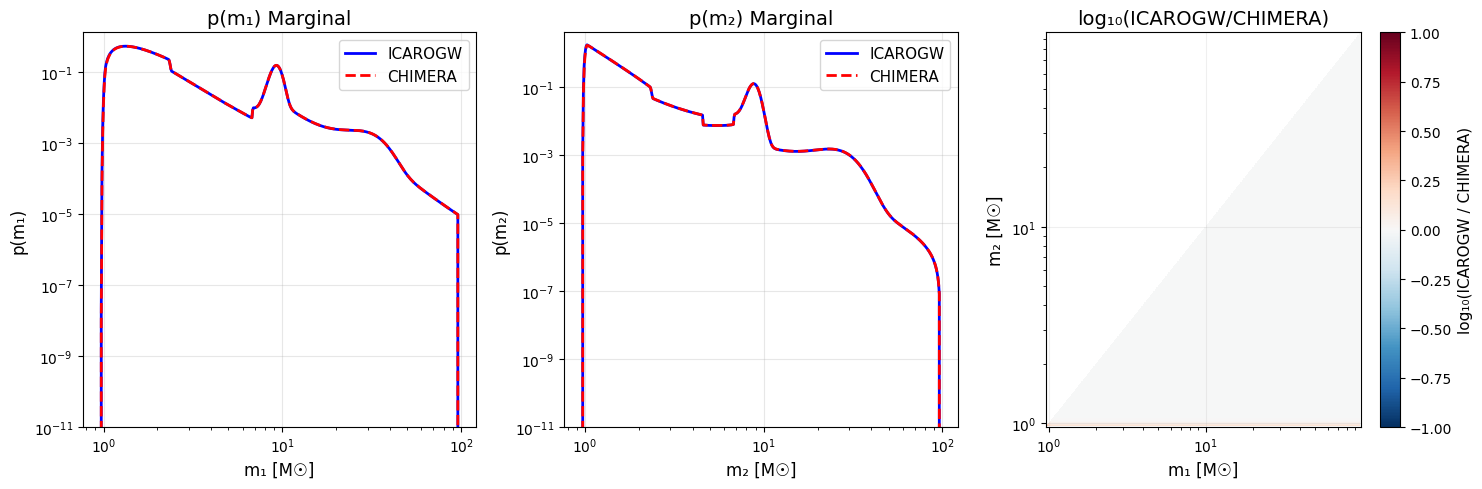

In [2]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')
sys.path.append('/leonardo/home/userexternal/mtagliaz/softwares/icarogw/')
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from icarogw.wrappers import m1m2_paired_massratio_bplmulti_dip
from CHIMERA.mass.paired import bpl_dip_two_peaks
from CHIMERA.mass import p_m1m2

params = {
    'mmin': 0.961834913949035,
    'mmax': 96.86391602156012,
    'alpha_1': 2.1553739953196223,
    'alpha_2': 1.848352853466305,
    'beta_bottom': 1.500961280411781,
    'beta_top': 2.5908978874521305,
    'mu_g_low': 9.056012551383695,
    'sigma_g_low': 0.6948024105466937,
    'mu_g_high': 27.134217763853904,
    'sigma_g_high': 8.384405984258168,
    'lambda_g': 0.2651222683400193,
    'lambda_g_low': 0.7091553393032455,
    'bottomsmooth': 0.07554021010270083,
    'topsmooth': 0.0991675925989498,
    'leftdip': 2.2922222205817913,
    'rightdip': 6.875503912163882,
    'leftdipsmooth': 0.12602841524720307,
    'rightdipsmooth': 0.1253143500,
    'deep': 0.4849206386665612
}

# ============================================================================
# ICAROGW setup
# ============================================================================

mass_icaro = m1m2_paired_massratio_bplmulti_dip()
mass_icaro.update(**params)
m_grid = np.logspace(np.log10(params['mmin']), np.log10(params['mmax']), 500)
m1_grid, m2_grid = np.meshgrid(m_grid, m_grid, indexing='ij')

# ICAROGW 2D PDF
icarogw_pdf_2d = mass_icaro.pdf(m1_grid, m2_grid)

# ICAROGW 1D marginals
icarogw_pdf_m1 = np.trapz(icarogw_pdf_2d, x=m_grid, axis=1)
icarogw_pdf_m1 = icarogw_pdf_m1 / np.trapz(icarogw_pdf_m1, x=m_grid)

icarogw_pdf_m2 = np.trapz(icarogw_pdf_2d, x=m_grid, axis=0)
icarogw_pdf_m2 = icarogw_pdf_m2 / np.trapz(icarogw_pdf_m2, x=m_grid)

# ============================================================================
# CHIMERA setup
# ============================================================================

mass_chimera = bpl_dip_two_peaks()
chimera_params = {
    'm_low': params['mmin'],
    'm_high': params['mmax'],
    'alpha_1': params['alpha_1'],
    'alpha_2': params['alpha_2'],
    'beta_bottom': params['beta_bottom'],
    'beta_top': params['beta_top'],
    'mu_g_low': params['mu_g_low'],
    'sigma_g_low': params['sigma_g_low'],
    'mu_g_high': params['mu_g_high'],
    'sigma_g_high': params['sigma_g_high'],
    'lambda_g': params['lambda_g'],
    'lambda_1': params['lambda_g_low'],
    'bottomsmooth': params['bottomsmooth'],
    'topsmooth': params['topsmooth'],
    'leftdip': params['leftdip'],
    'rightdip': params['rightdip'],
    'leftdipsmooth': params['leftdipsmooth'],
    'rightdipsmooth': params['rightdipsmooth'],
    'deep': params['deep'],
}
mass_chimera = mass_chimera.update(**chimera_params)

# CHIMERA 2D PDF
chimera_pdf_2d = p_m1m2(mass_chimera, jnp.asarray(m1_grid), jnp.asarray(m2_grid))
chimera_pdf_2d = np.asarray(chimera_pdf_2d)

# CHIMERA 1D marginals
chimera_pdf_m1 = np.trapz(chimera_pdf_2d, x=m_grid, axis=1)
chimera_pdf_m1 = chimera_pdf_m1 / np.trapz(chimera_pdf_m1, x=m_grid)

chimera_pdf_m2 = np.trapz(chimera_pdf_2d, x=m_grid, axis=0)
chimera_pdf_m2 = chimera_pdf_m2 / np.trapz(chimera_pdf_m2, x=m_grid)

# ============================================================================
# Plot: 3 panels
# ============================================================================

fig = plt.figure(figsize=(15, 5))

# --- Panel 1: p(m1) marginal ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.loglog(m_grid, icarogw_pdf_m1, 'b-', linewidth=2, label='ICAROGW')
ax1.loglog(m_grid, chimera_pdf_m1, 'r--', linewidth=2, label='CHIMERA')
ax1.set_xlabel('m₁ [M☉]', fontsize=12)
ax1.set_ylabel('p(m₁)', fontsize=12)
ax1.set_title('p(m₁) Marginal', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(1e-11, None)

# --- Panel 2: p(m2) marginal ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.loglog(m_grid, icarogw_pdf_m2, 'b-', linewidth=2, label='ICAROGW')
ax2.loglog(m_grid, chimera_pdf_m2, 'r--', linewidth=2, label='CHIMERA')
ax2.set_xlabel('m₂ [M☉]', fontsize=12)
ax2.set_ylabel('p(m₂)', fontsize=12)
ax2.set_title('p(m₂) Marginal', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(1e-11, None)

# --- Panel 3: 2D Difference (ICAROGW - CHIMERA) ---
ax3 = fig.add_subplot(1, 3, 3)
diff_2d = np.log10(icarogw_pdf_2d) - np.log10(chimera_pdf_2d)
# Mask regions where both are non-zero
mask = (icarogw_pdf_2d > 1e-30) & (chimera_pdf_2d > 1e-30)
diff_2d_masked = np.where(mask, diff_2d, np.nan)

im = ax3.pcolormesh(m1_grid, m2_grid, diff_2d_masked,
                    cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax3.set_xlabel('m₁ [M☉]', fontsize=12)
ax3.set_ylabel('m₂ [M☉]', fontsize=12)
ax3.set_title('log₁₀(ICAROGW/CHIMERA)', fontsize=14)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.2)
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('log₁₀(ICAROGW / CHIMERA)', fontsize=11)

plt.tight_layout()
plt.show()


In [3]:
m1 = jnp.linspace(mass_chimera.m_low, mass_chimera.m_high, 5000)
m1g = jnp.array([m1 for _ in range(300)])
m2g = m1g*0.9

p_m1m2(mass_chimera, m1g, m2g)
%timeit -n 10 p_m1m2(mass_chimera, m1g, m2g).block_until_ready()

448 ms ± 15.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
